In [21]:
#essential imports
import os
import re
import string
import math
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#NLP tools
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

#wordcloud + image handling
from wordcloud import WordCloud, STOPWORDS
from PIL import Image

#vectorizers + similarity metrics
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#interactive visualizaiton (to be added later)
import plotly.express as px

#supress warnings + set up plotting
warnings.filterwarnings("ignore")
%matplotlib inline

#NLTK downloads (robust check)
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")
    
nltk.download("stopwords")

#initialize stemmer
ps = PorterStemmer()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/isabellventouris/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Load inaugural speeches into DataFrames

I am analyzing four U.S. presidential inaugural addresses: Barack Obama (2009), Donald Trump (2017), George W. Bush (2001), and Bill Clinton (1997). Each speech is imported from a unstructured .txt file into a separate Pandas DataFrame. This format allows for consistent text preprocessing and comparative linguistic analysis across all four leaders.


In [22]:
df_Obama_Inaug = pd.read_csv('data/Obama2009.txt', on_bad_lines='skip',encoding='cp1252')
df_Obama_Inaug.head(3)

,I stand here today humbled by the task before us,grateful for the trust you have bestowed,mindful of the sacrifices borne by our ancestors. I thank President Bush for his service to our nation,as well as the generosity and cooperation he has shown throughout this transition.
Forty-four Americans have now taken the presidential oath. The words have been spoken during rising tides of prosperity and the still waters of peace. Yet,every so often the oath is taken amidst gathe...,America has carried on not simply because of ...,but because We the People have remained faith...,and true to our founding documents.
So it has been. So it must be with this generation of Americans.,NaN,NaN,NaN,NaN
That we are in the midst of crisis is now well understood. Our nation is at war,against a far-reaching network of violence an...,a consequence of greed and irresponsibility o...,but also our collective failure to make hard ...,NaN


In [23]:
df_Trump_Inaug = pd.read_csv('data/Text 3-Trump Inaug.2017.txt', on_bad_lines='skip',encoding='utf8')
df_Trump_Inaug.head(3)

,Chief Justice Roberts,President Carter,President Clinton,President Bush,President Obama,fellow Americans,and people of the world: thank you.
0,We,the citizens of America,are now joined in a great national effort to ...,NaN,NaN,NaN,NaN
1,Together,we will determine the course of America and t...,NaN,NaN,NaN,NaN,NaN
2,We will face challenges. We will confront hard...,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df_GWBush_Inaug = pd.read_csv('data/GWBush-Inaug-2001.txt', on_bad_lines='skip',encoding='utf8')
df_GWBush_Inaug.head(3)

,President Clinton,distinguished guests and my fellow citizens,the peaceful transfer of authority is rare in history,yet common in our country. With a simple oath,we affirm old traditions and make new beginnings.
0,As I begin,I thank President Clinton for his service to ...,NaN,NaN,NaN
1,And I thank Vice President Gore for a contest ...,NaN,NaN,NaN,NaN
2,I am honored and humbled to stand here,where so many of America's leaders have come ...,and so many will follow.,NaN,NaN


In [25]:
df_Clinton_Inaug = pd.read_csv('data/Clinton_Inaug_1993.txt', on_bad_lines='skip',encoding='utf8')
df_Clinton_Inaug.head(3)

,My fellow citizens,today we celebrate the mystery of American renewal. This ceremony is held in the depth of winter,but by the words we speak and the faces we show the world,we force the spring,a spring reborn in the world's oldest democracy that brings forth the vision and courage to reinvent America. When our Founders boldly declared America's independence to the world and our purposes to the Almighty,they knew that America,to endure,would have to change; not change for change's sake but change to preserve America's ideals: life,liberty,the pursuit of happiness. Though we marched to the music of our time,our mission is timeless. Each generation of Americans must define what it means to be an American.
0,On behalf of our Nation,I salute my predecessor,President Bush,for his half-century of service to America. A...,fascism,and communism.,NaN,NaN,NaN,NaN,NaN
1,Today,a generation raised in the shadows of the col...,we inherit an economy that is still the world...,stagnant wages,increasing inequality,and deep divisions among our own people.,NaN,NaN,NaN,NaN,NaN
2,When George Washington first took the oath I h...,news traveled slowly across the land by horse...,the sights and sounds of this ceremony are br...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Concatenate text columns into unified speech lines

Each speech DataFrame initially contains multiple columns representing segmented lines or phrases. To create coherent text entries for analysis, we concatenate these columns row-wise into single strings, joining non-null elements with commas. This step transforms fragmented text segments into more meaningful units suitable for downstream tokenization and processing.

In [26]:
df_Obama_Inaug = df_Obama_Inaug[df_Obama_Inaug.columns[1:]].apply(
    lambda x: ','.join(x.dropna().astype(str)),
    axis=1
)
df_Obama_Inaug

Forty-four Americans have now taken the presidential oath. The words have been spoken during rising tides of prosperity and the still waters of peace. Yet                                                                                                                     America has carried on not simply because of ...
So it has been. So it must be with this generation of Americans.                                                                                                                                                                                                                                                               
That we are in the midst of crisis is now well understood. Our nation is at war                                                                                                                                                                                                a consequence of greed and irresponsibility o...
These are the indicators of crisis      

In [27]:
df_Trump_Inaug = df_Trump_Inaug[df_Trump_Inaug.columns[1:]].apply(
    lambda x: ','.join(x.dropna().astype(str)),
    axis=1
)
df_Trump_Inaug

0      the citizens of America, are now joined in a ...
1      we will determine the course of America and t...
2                                                      
3      we gather on these steps to carry out the ord...
4      however, has very special meaning. Because to...
                            ...                        
69                   We Will Make America Strong Again.
70                                                     
71                                                     
72                                                     
73     Yes, Together, We Will Make America Great Aga...
Length: 74, dtype: object

In [28]:
df_GWBush_Inaug = df_GWBush_Inaug[df_GWBush_Inaug.columns[1:]].apply(
    lambda x: ','.join(x.dropna().astype(str)),
    axis=1
)
df_GWBush_Inaug

0      I thank President Clinton for his service to ...
1                                                      
2      where so many of America's leaders have come ...
3      united across the generations by grand and en...
4      that everyone deserves a chance, that no insi...
5      and sometimes delayed, we must follow no othe...
6      America's faith in freedom and democracy was ...
7      it is the inborn hope of our humanity, an ide...
8      and we will not allow it. Our unity, our unio...
9                                                      
10                                                     
11     we affirm a new commitment to live out our na...
12     at its best, matches a commitment to principl...
13     in a time of peace, the stakes of our debates...
14     it will not be led. If we do not turn the hea...
15     of community over chaos. And this commitment,...
16                     at its best, is also courageous.
17     when defending common dangers defined our

In [29]:
df_Clinton_Inaug = df_Clinton_Inaug[df_Clinton_Inaug.columns[1:]].apply(
    lambda x: ','.join(x.dropna().astype(str)),
    axis=1
)
df_Clinton_Inaug

0      I salute my predecessor, President Bush, for ...
1      a generation raised in the shadows of the col...
2      news traveled slowly across the land by horse...
3      great and small; when the fear of crime robs ...
4       and a new season of American renewal has begun.
5      we must be bold. We must do what no generatio...
6      from whom we have borrowed our planet, and to...
7      we must revitalize our democracy. This beauti...
8      we must meet challenges abroad as well as at ...
9      the Presidency, and the political process its...
10     you, too, must play your part in our renewal....
11     an idea born in revolution and renewed throug...
12     my fellow Americans, as we stand at the edge ...
13                               and God bless you all.
dtype: object

### Create bag-of-words model for inaugural speeches

Using scikit-learn's CountVectorizer, I build a vocabulary from everyone's inaugural speech text and transform it into a sparse Bag-of-Words (BoW) matrix. This matrix represents the frequency of each vocabulary word across speech segments (rows), enabling quantitative text analysis while efficiently storing only nonzero counts.

In [30]:
#initialize CountVectorizer and fit it to Clinton speech DataFrame
vectorizer_clinton = CountVectorizer()
vectorizer_clinton.fit(df_Clinton_Inaug)

#transform text into Bag-of-Words sparse matrix
bow_model_Clinton = vectorizer_clinton.transform(df_Clinton_Inaug)

#newly added to improve visualization: convert sparse matrix to readable DataFrame
bow_df_clinton = pd.DataFrame(
    bow_model_Clinton.toarray(),
    columns=vectorizer_clinton.get_feature_names_out()
)

#display first 3 rows
bow_df_clinton.head(3)

,21st,abiding,about,abroad,across,act,advantage,affect,aids,all,...,with,women,work,world,worry,yes,yesterdays,you,young,your
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
2,0,0,0,0,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [31]:
#initialize CountVectorizer and fit it to Bush speech DataFrame
vectorizer_bush = CountVectorizer()
vectorizer_bush.fit(df_GWBush_Inaug)

#transform text into Bag-of-Words sparse matrix
bow_model_Bush = vectorizer_bush.transform(df_GWBush_Inaug)

#newly added to improve visualization: convert sparse matrix to readable DataFrame
bow_df_bush = pd.DataFrame(
    bow_model_Bush.toarray(),
    columns=vectorizer_bush.get_feature_names_out()
)

#display first 3 rows
bow_df_bush.head(3)

,225,abandonment,abuse,accomplishment,achieved,across,acts,affirm,after,against,...,without,work,working,wrong,wrote,years,yet,you,young,your
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
#initialize CountVectorizer and fit it to Obama speech DataFrame
vectorizer_obama = CountVectorizer()
vectorizer_obama.fit(df_Obama_Inaug)

#transform text into Bag-of-Words sparse matrix
bow_model_Obama = vectorizer_obama.transform(df_Obama_Inaug)

#newly added to improve visualization: convert sparse matrix to readable DataFrame
bow_df_obama = pd.DataFrame(
    bow_model_Obama.toarray(),
    columns=vectorizer_obama.get_feature_names_out()
)

#display first 3 rows
bow_df_obama.head(3)

,abandoned,ability,advancing,adversaries,afford,age,also,always,america,an,...,who,willing,willingness,with,without,words,workers,world,worn,would
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
#initialize CountVectorizer and fit it to Trump speech DataFrame
vectorizer_trump = CountVectorizer()
vectorizer_trump.fit(df_Trump_Inaug)

#transform text into Bag-of-Words sparse matrix
bow_model_Trump = vectorizer_trump.transform(df_Trump_Inaug)

#newly added to improve visualization: convert sparse matrix to readable DataFrame
bow_df_trump = pd.DataFrame(
    bow_model_Trump.toarray(),
    columns=vectorizer_trump.get_feature_names_out()
)

#display first 3 rows
bow_df_trump.head(3)

,about,across,administration,affairs,again,aid,airports,all,almighty,along,...,with,wonderful,words,workers,world,years,yes,you,young,your
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Custom Text Preprocessing and Bag-of-Words Construction

Now I define a function WordPreProcessing that performs the following steps on raw speech text data:

- Strips whitespace and normalizes spaces  
- Tokenizes into words using NLTK  
- Converts tokens to lowercase  
- Removes punctuation and English stopwords  
- Filters out non-alphanumeric characters  
- Applies Porter stemming  
- Constructs a vocabulary set and a Bag-of-Words (BoW) model represented as a list of word count dictionaries, one per text segment  

This custom preprocessing pipeline prepares the speeches for detailed linguistic and frequency analysis.

In [34]:

  
def WordPreProcessing(text_data):

    vocab = set() #vocabulary of unique stemmed tokens

    bow_model = [] #list to store word count dicts for each text segment

    for text in text_data:
        word_counts = {} #frequency dict for current segment

        text = text.strip() #trim whitespace

        text = " ".join(text.split()) #normalize spaces

        tokens = nltk.word_tokenize(text) #tokenize text
        lowercased_tokens = [token.lower() for token in tokens] #lowercase

        filtered_tokens = [token for token in lowercased_tokens if token not in string.punctuation] #remove punctuation

        stopwords = nltk.corpus.stopwords.words("english") #English stopwords list

        filtered_tokens = [token for token in filtered_tokens if token not in stopwords] #remove stopwords

        #remove non-alphanumeric characters from tokens
        filtered_tokens = [re.sub(r'[^a-zA-Z0-9\s]+','',token) for token in filtered_tokens] 

        stemmer = nltk.stem.PorterStemmer() #Porter stemmer instance

        stemmed_tokens = [stemmer.stem(token) for token in filtered_tokens] #apply stemming

        last_stage = [token for token in stemmed_tokens if token] #remove empty tokens

        vocab.update(last_stage) #update vocabulary set

        #count word frequencies in current segment
        for word in last_stage:
            if word in word_counts:
                word_counts[word] += 1
            else:
                word_counts[word] = 1

        bow_model.append(word_counts) #append segment BoW to model
    return bow_model

### Apply Preprocessing to Speeches

I apply the WordPreProcessing function to the inaugural speeches DataFrame to generate a Bag-of-Words model, capturing stemmed word frequencies per text segment.

In [35]:
#transform speeches into a Bag-of-Words (BoW) list of dictionaries
Clinton_Speech_BOW = WordPreProcessing(df_Clinton_Inaug)
Obama_Speech_BOW = WordPreProcessing(df_Obama_Inaug)
Bush_Speech_BOW = WordPreProcessing(df_GWBush_Inaug)
Trump_Speech_BOW = WordPreProcessing(df_Trump_Inaug)

In [36]:
print(f"Clinton speech segments: {len(Clinton_Speech_BOW)}")
print(f"Obama speech segments: {len(Obama_Speech_BOW)}")
print(f"Bush speech segments: {len(Bush_Speech_BOW)}")
print(f"Trump speech segments: {len(Trump_Speech_BOW)}")

Clinton speech segments: 14
Obama speech segments: 21
Bush speech segments: 44
Trump speech segments: 74


### Visualize Word Frequencies from Bag-of-Words Model

The display_Frequencies function extracts word-frequency pairs from a Bag-of-Words list of dictionaries and creates an interactive bar chart using Plotly. This visualization helps identify the most common stemmed words in each speech, enabling side-by-side comparison across different inaugural addresses.


In [37]:
def Return_df(speech):
    words = []
    count = []
    for i in range(len(speech)):
        for keys in speech[i].keys():
            words.append(keys)
        for values in speech[i].values():
            count.append(values)
    return pd.DataFrame({"words":words,"variable Count":count})

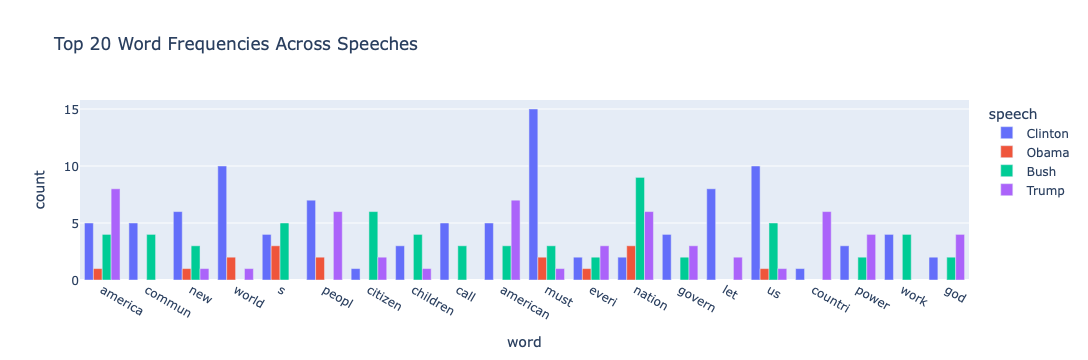

In [54]:
from collections import Counter
import pandas as pd
import plotly.express as px

def aggregate_word_counts(speech_bow):
    total_counts = Counter()
    for segment in speech_bow:
        total_counts.update(segment)
    return total_counts

#aggregate word counts for all speeches
counts_clinton = aggregate_word_counts(Clinton_Speech_BOW)
counts_obama = aggregate_word_counts(Obama_Speech_BOW)
counts_bush = aggregate_word_counts(Bush_Speech_BOW)
counts_trump = aggregate_word_counts(Trump_Speech_BOW)

#convert to DataFrame with speech label
def to_df(counts, label):
    return pd.DataFrame({
        'word': list(counts.keys()),
        'count': list(counts.values()),
        'speech': label
    })

df_clinton = to_df(counts_clinton, 'Clinton')
df_obama = to_df(counts_obama, 'Obama')
df_bush = to_df(counts_bush, 'Bush')
df_trump = to_df(counts_trump, 'Trump')

#combine all into one DataFrame
df_all = pd.concat([df_clinton, df_obama, df_bush, df_trump])

#filter to top N words by total count
top_words = df_all.groupby('word')['count'].sum().nlargest(20).index
df_filtered = df_all[df_all['word'].isin(top_words)]

#plot grouped bar chart
fig = px.bar(df_filtered, x='word', y='count', color='speech', barmode='group',
             title='Top 20 Word Frequencies Across Speeches')

#save as interactive HTML file
fig.write_html("top_word_frequencies.html")

#display bar chart
fig.show()


In [39]:
#transform speeches into a Bag-of-Words list of dictionaries
Clinton_speech_df = Return_df(Clinton_Speech_BOW)
Bush_speech_df = Return_df(Bush_Speech_BOW)
Obama_speech_df = Return_df(Obama_Speech_BOW)
Trump_speech_df = Return_df(Trump_Speech_BOW)

#sort each DataFrame by count and select top 15 words
TopTenC = Clinton_speech_df.sort_values(['variable Count'], ascending=False).iloc[:15,]
TopTenC = TopTenC.reset_index(drop=True)
TopTenC = TopTenC.rename(columns={"words": "Clinton", "variable Count": "Count"})

TopTenB = Bush_speech_df.sort_values(['variable Count'], ascending=False).iloc[:15,]
TopTenB = TopTenB.reset_index(drop=True)
TopTenB = TopTenB.rename(columns={"words": "Bush", "variable Count": "Count"})

TopTenO = Obama_speech_df.sort_values(['variable Count'], ascending=False).iloc[:15,]
TopTenO = TopTenO.reset_index(drop=True)
TopTenO = TopTenO.rename(columns={"words": "Obama", "variable Count": "Count"})

TopTenT = Trump_speech_df.sort_values(['variable Count'], ascending=False).iloc[:15,]
TopTenT = TopTenT.reset_index(drop=True)
TopTenT = TopTenT.rename(columns={"words": "Trump", "variable Count": "Count"})

In [40]:
#combine the top 15 words from all speeches side-by-side
result = pd.concat([TopTenC, TopTenB, TopTenO, TopTenT], axis=1)
result

,Clinton,Count,Bush,Count,Obama,Count,Trump,Count
0,world,6,citizen,4,prosper,3,bless,2
1,must,6,us,2,world,2,american,2
2,us,5,spirit,2,s,2,ocean,2
3,peopl,5,new,2,see,2,industri,2
4,let,4,work,2,hour,2,obama,2
5,idea,4,civil,2,chang,2,moment,2
6,capit,3,common,2,selfless,1,left,2
7,us,3,purpos,2,s,1,one,2
8,let,3,find,2,resourc,1,transfer,2
9,respons,3,must,2,without,1,power,2


## Prepare Raw Speech Texts for Cosine Similarity
I load and preprocess each inaugural speech text file. The goal is to extract the full text, convert it to lowercase, and structure it as a single string for vectorization and similarity analysis.

In [41]:
#load Clinton's speech and combine all rows/columns into a single lowercase string
W = pd.read_csv('data/Clinton_Inaug_1993.txt', on_bad_lines='skip', encoding='utf8')

#drop first column, join remaining columns per row, convert to string
W = W[W.columns[1:]].apply(
    lambda x: ','.join(x.dropna().astype(str)),
    axis=1
)

#convert entire Series to a single string and lowercase it
W = W.to_string().lower()

#repeat the same process for George W. Bush's inaugural speech
X = pd.read_csv('data/GWBush-Inaug-2001.txt', on_bad_lines='skip', encoding='utf8')
X = X[X.columns[1:]].apply(lambda x: ','.join(x.dropna().astype(str)), axis=1)
X = X.to_string().lower()

#repeat for Obama's inaugural speech (adjusted encoding for special characters)
Y = pd.read_csv('data/Obama2009.txt', on_bad_lines='skip', encoding='cp1252')
Y = Y[Y.columns[1:]].apply(lambda x: ','.join(x.dropna().astype(str)), axis=1)
Y = Y.to_string().lower()

#repeat for Trump's inaugural speech
Z = pd.read_csv('data/Text 3-Trump Inaug.2017.txt', on_bad_lines='skip', encoding='utf8')
Z = Z[Z.columns[1:]].apply(lambda x: ','.join(x.dropna().astype(str)), axis=1)
Z = Z.to_string().lower()


In [42]:
#Clinton vs Bush
#tokenization 
W_list = word_tokenize(W)  
X_list = word_tokenize(X) 
  
#sw contains the list of stopwords 
sw = stopwords.words('english')  
l1 =[];l2 =[] 
  
#remove stop words from the string 
W_set = {w for w in W_list if not w in sw}  
X_set = {w for w in X_list if not w in sw} 
  
#form a set containing keywords of both strings  
rvector = W_set.union(X_set)  
for w in rvector: 
    if w in W_set: l1.append(1) #create a vector 
    else: l1.append(0) 
    if w in X_set: l2.append(1) 
    else: l2.append(0) 
c = 0
  
#cosine formula  
for i in range(len(rvector)): 
        c+= l1[i]*l2[i] 
cosine = c / float((sum(l1)*sum(l2))**0.5) 
print("similarity: ", cosine)

similarity:  0.23495144355142164


In [43]:
#Bush vs Obama
#tokenization 
X_list = word_tokenize(X)  
Y_list = word_tokenize(Y) 
  
#sw contains the list of stopwords 
sw = stopwords.words('english')  
l1 =[];l2 =[] 
  
#remove stop words from the string 
X_set = {w for w in X_list if not w in sw}  
Y_set = {w for w in Y_list if not w in sw} 
  
#form a set containing keywords of both strings  
rvector = X_set.union(Y_set)  
for w in rvector: 
    if w in X_set: l1.append(1) #create a vector 
    else: l1.append(0) 
    if w in Y_set: l2.append(1) 
    else: l2.append(0) 
c = 0
  
#cosine formula  
for i in range(len(rvector)): 
        c+= l1[i]*l2[i] 
cosine = c / float((sum(l1)*sum(l2))**0.5) 
print("similarity: ", cosine)

similarity:  0.15839698777049716


In [44]:
#Obama vs Trump
#tokenization 
Y_list = word_tokenize(Y)  
Z_list = word_tokenize(Z) 
  
#sw contains the list of stopwords 
sw = stopwords.words('english')  
l1 =[];l2 =[] 
  
#remove stop words from the string 
Y_set = {w for w in Y_list if not w in sw}  
Z_set = {w for w in Z_list if not w in sw} 
  
#form a set containing keywords of both strings  
rvector = Y_set.union(Z_set)  
for w in rvector: 
    if w in Y_set: l1.append(1) #create a vector 
    else: l1.append(0) 
    if w in Z_set: l2.append(1) 
    else: l2.append(0) 
c = 0
  
#cosine formula  
for i in range(len(rvector)): 
        c+= l1[i]*l2[i] 
cosine = c / float((sum(l1)*sum(l2))**0.5) 
print("similarity: ", cosine)

similarity:  0.13003912165257484


In [45]:
#Obama vs Clinton
#tokenization 
Y_list = word_tokenize(Y)  
W_list = word_tokenize(W) 
  
#sw contains the list of stopwords 
sw = stopwords.words('english')  
l1 =[];l2 =[] 
  
#remove stop words from the string 
Y_set = {w for w in Y_list if not w in sw}  
W_set = {w for w in W_list if not w in sw} 
  
#form a set containing keywords of both strings  
rvector = Y_set.union(W_set)  
for w in rvector: 
    if w in Y_set: l1.append(1) #create a vector 
    else: l1.append(0) 
    if w in W_set: l2.append(1) 
    else: l2.append(0) 
c = 0
  
#cosine formula  
for i in range(len(rvector)): 
        c+= l1[i]*l2[i] 
cosine = c / float((sum(l1)*sum(l2))**0.5) 
print("similarity: ", cosine)

similarity:  0.12818706987301454


In [46]:
#Clinton vs Trump
#tokenization 
W_list = word_tokenize(W)  
Z_list = word_tokenize(Z) 
  
# sw contains the list of stopwords 
sw = stopwords.words('english')  
l1 =[];l2 =[] 
  
#remove stop words from the string 
W_set = {w for w in W_list if not w in sw}  
Z_set = {w for w in Z_list if not w in sw} 
  
#form a set containing keywords of both strings  
rvector = W_set.union(Z_set)  
for w in rvector: 
    if w in W_set: l1.append(1) # create a vector 
    else: l1.append(0) 
    if w in Z_set: l2.append(1) 
    else: l2.append(0) 
c = 0
  
#cosine formula  
for i in range(len(rvector)): 
        c+= l1[i]*l2[i] 
cosine = c / float((sum(l1)*sum(l2))**0.5) 
print("similarity: ", cosine)

similarity:  0.1840294470674847


In [47]:
#Bush vs Trump
#tokenization 
X_list = word_tokenize(X)  
Z_list = word_tokenize(Z) 
  
#sw contains the list of stopwords 
sw = stopwords.words('english')  
l1 =[];l2 =[] 
  
#remove stop words from the string 
X_set = {w for w in X_list if not w in sw}  
Z_set = {w for w in Z_list if not w in sw} 
  
#form a set containing keywords of both strings  
rvector = X_set.union(Z_set)  
for w in rvector: 
    if w in X_set: l1.append(1) #create a vector 
    else: l1.append(0) 
    if w in Z_set: l2.append(1) 
    else: l2.append(0) 
c = 0
  
#cosine formula  
for i in range(len(rvector)): 
        c+= l1[i]*l2[i] 
cosine = c / float((sum(l1)*sum(l2))**0.5) 
print("similarity: ", cosine)

similarity:  0.2867214478562801


### Sentiment analysis across speeches using bing lexicon

I analyze the emotional tone of each speech by mapping words to positive or negative sentiment using the Bing Liu opinion lexicon. The sentiment scores are aggregated by speech segment to visualize how emotional polarity shifts throughout each address.

In [48]:
#file paths for all speeches
files = ["data/Clinton_Inaug_1993.txt", "data/GWBush-Inaug-2001.txt", "data/Obama2009.txt", "data/Text 3-Trump Inaug.2017.txt"]


#list to store results: filename, line_number, word
corpus = []

#loop through each speech file
for file in files: 

    #open the file using latin1 encoding to avoid decode errors
    with open(file, encoding = 'latin1') as f:
        lines = f.readlines()
    
    i = 1 #initialize line counter

    #iterate through each line in the file
    for line_number in lines: 

        #split the line into individual words
        words = line_number.split()
        #store each word along with its file and line number
        for w in words:
            corpus.append([file, i, w])
                
        i += 1 #move to next line
    
#DataFrame transition for easier readability of corpus structure
Corpus_df = pd.DataFrame(corpus, columns=['speech', 'line', 'word'])

#show first 5 rows
Corpus_df.head()

,speech,line,word
0,data/Clinton_Inaug_1993.txt,1,My
1,data/Clinton_Inaug_1993.txt,1,fellow
2,data/Clinton_Inaug_1993.txt,1,"citizens,"
3,data/Clinton_Inaug_1993.txt,1,today
4,data/Clinton_Inaug_1993.txt,1,we


In [49]:
#get list of English stopwords from NLTK
stop_words = list(stopwords.words('english'))
stop_words

#remove stopwords from corpus with list comprehension
#better than modifyign by iterating over list (might cause bugs)
corpus = [word for word in corpus if word[2].lower() not in stop_words]

#print the number of words remaining after stopword removal
len(corpus)

3542

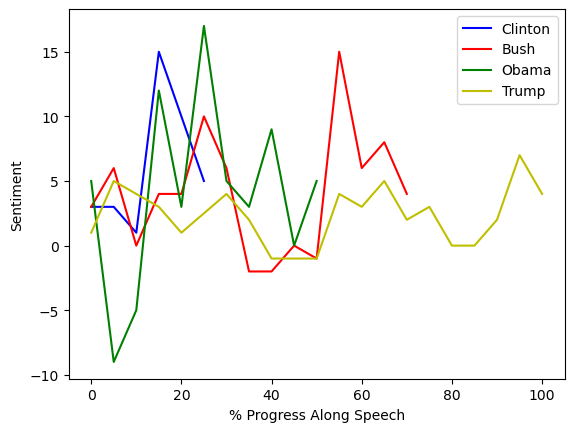

In [50]:
#convert corpus list into DF
Corpus = pd.DataFrame(corpus, columns = ['speech', 'line', 'word'])

#remove punctuation from words using regex
Corpus["word"] = Corpus['word'].str.replace('[^\w\s]','', regex='True')

#load Bing Liu sentiment lexicon
df_bing = pd.read_csv('data/bing.csv')

#merge speech corpus with sentiment lexicon to assign sentiment scores to matched words
result = Corpus.merge(df_bing, on='word')

#convert sentiment labels to numerical values: positive = +1, negative = –1
result['sentiment'] = result['sentiment'].replace({'positive': 1, 'negative': -1})

#bin each speech into 5% segments to track sentiment progression
result['percentage'] = round(result['line'] / result['line'].max() * 100 / 5) * 5

#filter sentiment data by individual speech
c1993 = result[result['speech'] == 'data/Clinton_Inaug_1993.txt']
b2001 = result[result['speech'] == 'data/GWBush-Inaug-2001.txt']
o2009 = result[result['speech'] == 'data/Obama2009.txt']
t2017 = result[result['speech'] == 'data/Text 3-Trump Inaug.2017.txt']

#group sentiment by percentage segment and sum the scores
c1993a = c1993.groupby('percentage')['sentiment'].sum()
b2001a = b2001.groupby('percentage')['sentiment'].sum()
o2009a = o2009.groupby('percentage')['sentiment'].sum()
t2017a = t2017.groupby('percentage')['sentiment'].sum()

#plot sentiment trends across speeches
plt.plot(c1993a, 'b', label='Clinton')
plt.plot(b2001a, 'r', label='Bush')
plt.plot(o2009a, 'g', label='Obama')
plt.plot(t2017a, 'y', label='Trump')
plt.xlabel('% Progress Along Speech')
plt.ylabel('Sentiment')
plt.legend()
plt.savefig("images/sentiment_progression.png", dpi=300)
plt.show()

### Compute Cosine Similarity Between Speeches

In [51]:
#create DataFrame for word frequency by speech
pw = Corpus[['speech', 'word']]
d = pw.groupby(['speech', 'word']).size().reset_index(name='n')

#convert words to document-term matrix
vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform(d['word'])

#convert to DataFrame and group by speech (fix grouping to use actual speech labels)
dtm_df = pd.DataFrame(dtm.toarray(), columns=vectorizer.get_feature_names_out())
dtm_df['speech'] = d['speech']  # attach speech info back
new_df = dtm_df.groupby('speech').sum()

#transpose to get word vectors per speech
new = new_df.transpose()

#check for zero-variance columns which will cause NaNs in correlation --> these speeches will have a few
zero_var_cols = new.columns[new.std() == 0]
if len(zero_var_cols) > 0:
    print("columns with zero variance (will cause NaNs in correlation):")
    print(zero_var_cols)

#drop problematic columns
new = new.drop(columns=zero_var_cols)

#compute cosine similarity via correlation matrix
cosine_sim_matrix = new.corr()
cosine_sim_matrix


speech,data/Clinton_Inaug_1993.txt,data/GWBush-Inaug-2001.txt,data/Obama2009.txt,data/Text 3-Trump Inaug.2017.txt
speech,,,,
data/Clinton_Inaug_1993.txt,1.000000,-0.009867,-0.119409,-0.011685
data/GWBush-Inaug-2001.txt,-0.009867,1.000000,-0.151874,-0.063291
data/Obama2009.txt,-0.119409,-0.151874,1.000000,-0.159750
data/Text 3-Trump Inaug.2017.txt,-0.011685,-0.063291,-0.159750,1.000000


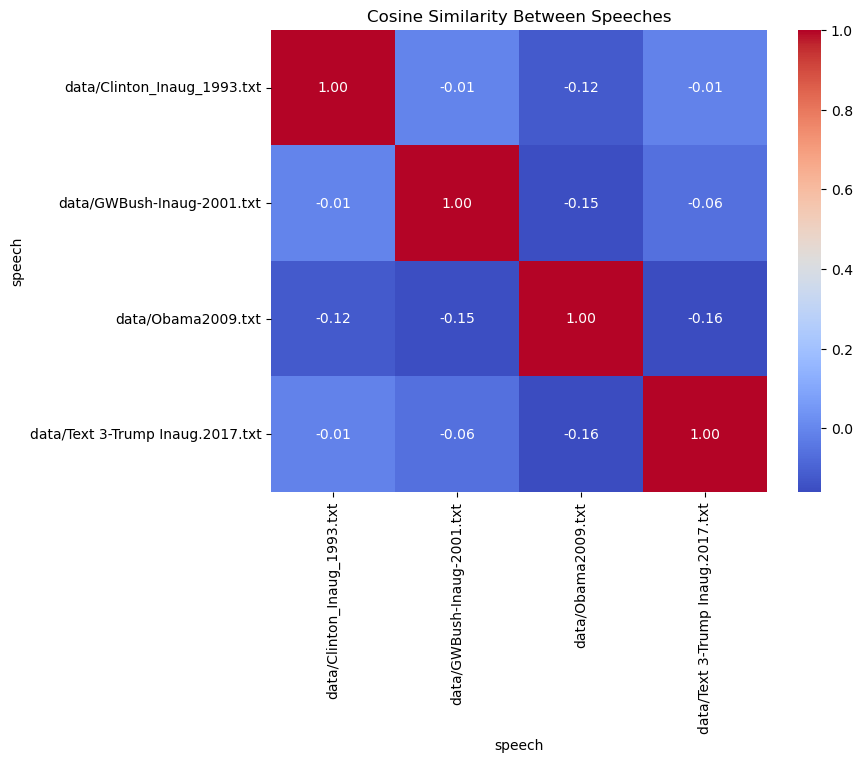

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(cosine_sim_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cosine Similarity Between Speeches")
plt.savefig("images/cosine_similarity_heatmap.png", dpi=300)
plt.show()


### Creating WordClouds

I am creating wordclouds to visualize the most frequent words of every speech

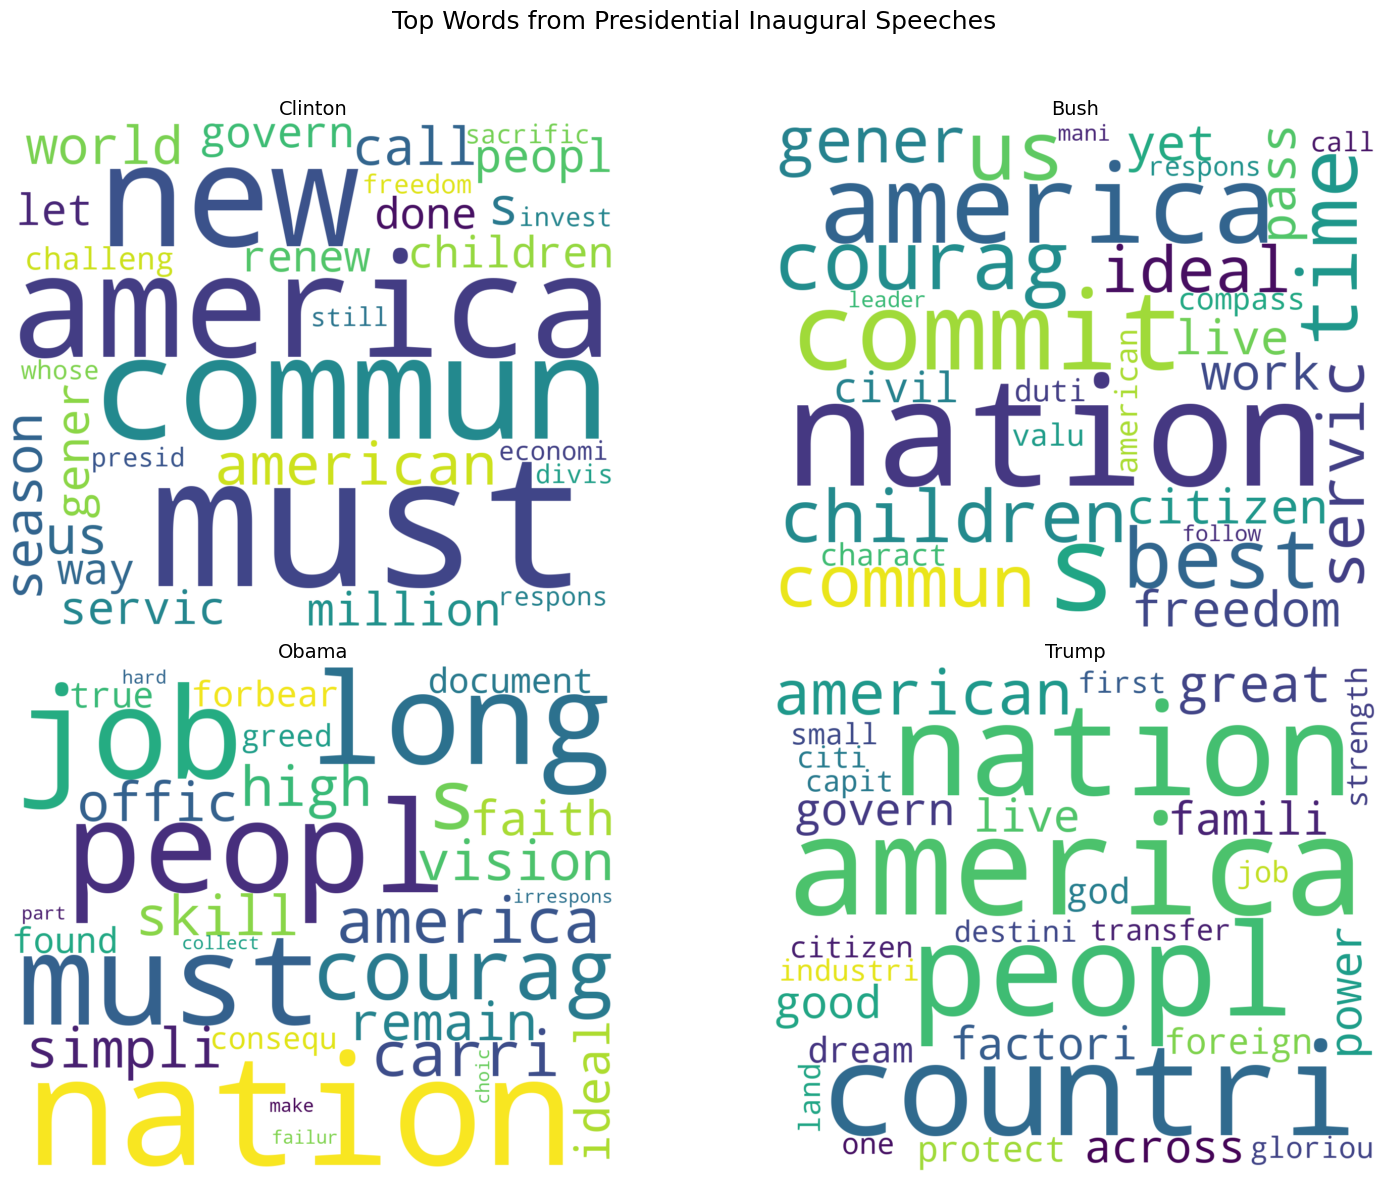

In [53]:
#helper function: generate a word cloud from a Bag-of-Words list
def generate_wordcloud(bow_list):
    word_array = np.array(bow_list).tolist()
    cloud_string = ' '.join([' '.join(segment) for segment in word_array])
    wordcloud = WordCloud(
        stopwords=STOPWORDS,
        max_words=30,
        background_color='white',
        width=1200,
        height=1000
    ).generate(cloud_string)
    return wordcloud

#word clouds for each speech
wordcloud_clinton = generate_wordcloud(Clinton_Speech_BOW)
wordcloud_bush    = generate_wordcloud(Bush_Speech_BOW)
wordcloud_obama   = generate_wordcloud(Obama_Speech_BOW)
wordcloud_trump   = generate_wordcloud(Trump_Speech_BOW)

#display all word clouds in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

presidents = ["Clinton", "Bush", "Obama", "Trump"]
wordclouds = [wordcloud_clinton, wordcloud_bush, wordcloud_obama, wordcloud_trump]

for ax, wc, title in zip(axs.flatten(), wordclouds, presidents):
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"{title}", fontsize=14)
    ax.axis('off')

plt.suptitle("Top Words from Presidential Inaugural Speeches", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("images/wordcloud_grid.png", dpi=300)
plt.show()